In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import sys
sys.path.append(f"./../")

# Import the BWT module
from src.bwt import QuantumWalkBWT

In [2]:
def analyze_analytical_hitting_times(heights=range(2, 11), optimization_method='gradient'):
    """
    Analyze how analytical hitting time scales with BWT height by directly maximizing 
    the theoretical exit probability formula. Shows a clean plot of hitting time vs height only.
    
    Args:
        heights: List or range of tree heights to analyze
        optimization_method: Which method to use for finding maximum:
                            'gradient' - gradient-based optimization (faster)
                            'root' - root finding of derivative (more precise)
        
    Returns:
        fig: The matplotlib figure showing the hitting time vs height plot
        results: List of dictionaries with results for each height
    """
    print("\n=== Analytical BWT Quantum Walk Hitting Time Analysis ===")
    print(f"Finding true hitting times by maximizing the exit probability formula:")
    print(r"∑_E |⟨E|1⟩|² |⟨E|2n⟩|² + ∑_{E≠E'} [(1-e^(-i(E-E')τ))/(i(E-E')τ)] ⟨2n|E⟩⟨E|1⟩⟨1|E'⟩⟨E'|2n⟩")
    print(f"\nUsing optimization method: {optimization_method}")
    
    # Calculate hitting times by maximizing the exit probability formula
    results = []
    for h in heights:
        print(f"\nProcessing height {h}...")
        start_time = time.time()
        
        # Create a quantum walk object
        qwalk = QuantumWalkBWT(height=h)
        
        # Find hitting time by maximizing exit probability
        if optimization_method == 'gradient':
            # Use gradient-based optimization (faster)
            hitting_t, max_p = qwalk.optimize_hitting_time_gradient()
        else:
            # Use root finding of derivative (more precise)
            hitting_t, max_p = qwalk.analytical_hitting_time()
        
        elapsed = time.time() - start_time
        
        # Store results
        results.append({
            "height": h,
            "hitting_time": hitting_t,
            "max_probability": max_p,
            "computation_time": elapsed
        })
        
        print(f"Height {h}: Hitting Time = {hitting_t:.6f}, Max Probability = {max_p:.6f}")
        print(f"Computation took {elapsed:.2f} seconds")

    # Create summary table
    print("\n=== Analytical Hitting Time Results ===")
    print(f"{'Height':<8} {'Hitting Time':<15} {'Max Probability':<15}")
    print(f"{'------':<8} {'------------':<15} {'---------------':<15}")

    for r in results:
        print(f"{r['height']:<8} {r['hitting_time']:<15.6f} {r['max_probability']:<15.6f}")

    # Create clean plot of hitting time vs height
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Extract data
    h_values = [r["height"] for r in results]
    hitting_times = [r["hitting_time"] for r in results]
    
    # Plot the analytical hitting times
    ax.plot(h_values, hitting_times, "bo-", linewidth=2.5, markersize=10, 
           label="Analytical Hitting Time")
    
    # Add best fit line
    if len(h_values) > 2:  # Need at least 3 points for meaningful fit
        # Fit a linear function: a*x + b
        coeffs = np.polyfit(h_values, hitting_times, 1)
        poly = np.poly1d(coeffs)
        
        # Create points for the fit line
        x_fit = np.linspace(min(h_values), max(h_values), 100)
        y_fit = poly(x_fit)
        
        # Plot the fit line
        ax.plot(x_fit, y_fit, "r--", linewidth=1.5, 
               label=f"Linear fit: {coeffs[0]:.4f}n + {coeffs[1]:.4f}")
        
        # Print equation
        print(f"\nBest fit line: y = {coeffs[0]:.6f}n + {coeffs[1]:.6f}")
        
        # Calculate and print R-squared value
        y_mean = np.mean(hitting_times)
        ss_total = sum((hitting_times - y_mean)**2)
        ss_residual = sum((hitting_times - poly(h_values))**2)
        r_squared = 1 - (ss_residual / ss_total)
        print(f"R² value: {r_squared:.6f}")
        
        # # Print the fitting equation on the plot
        # ax.text(0.05, 0.95, f"Fit: y = {coeffs[0]:.4f}n + {coeffs[1]:.4f}\nR² = {r_squared:.4f}", 
        #        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        #        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Set labels and titles
    ax.set_title(f"Analytical Hitting Time vs. BWT Height", fontsize=14)
    ax.set_xlabel("Tree Height (n)", fontsize=12)
    ax.set_ylabel("Hitting Time", fontsize=12)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Add legend
    ax.legend(fontsize=12, loc='upper left')
    
    # Add annotations showing the analytical hitting time values
    for i, h in enumerate(h_values):
        ax.annotate(f"{hitting_times[i]:.2f}", 
                   xy=(h, hitting_times[i]),
                   xytext=(h, hitting_times[i] + 0.5),
                   fontsize=10,
                   ha='center',
                   va='bottom',
                   arrowprops=dict(arrowstyle="->", lw=1, color='blue'))
    
    # Save figure
    plt.tight_layout()
    plt.savefig(f"./bwt_results/analytical_hitting_time_vs_height_{optimization_method}.pdf", dpi=300)
    plt.show()
    
    return fig, results

=== Binary Welded Tree Quantum Walk Analysis ===

Analyzing analytical hitting times for different tree heights...

=== Analytical BWT Quantum Walk Hitting Time Analysis ===
Finding true hitting times by maximizing the exit probability formula:
∑_E |⟨E|1⟩|² |⟨E|2n⟩|² + ∑_{E≠E'} [(1-e^(-i(E-E')τ))/(i(E-E')τ)] ⟨2n|E⟩⟨E|1⟩⟨1|E'⟩⟨E'|2n⟩

Using optimization method: gradient

Processing height 2...
Height 2: Hitting Time = 4.096923, Max Probability = 0.343897
Computation took 0.01 seconds

Processing height 3...
Height 3: Hitting Time = 13.383579, Max Probability = 0.183190
Computation took 0.01 seconds

Processing height 4...
Height 4: Hitting Time = 16.247706, Max Probability = 0.162733
Computation took 0.02 seconds

Processing height 5...
Height 5: Hitting Time = 19.693717, Max Probability = 0.134707
Computation took 0.03 seconds

Processing height 6...
Height 6: Hitting Time = 23.344555, Max Probability = 0.109498
Computation took 0.07 seconds

Processing height 7...
Height 7: Hitting Ti

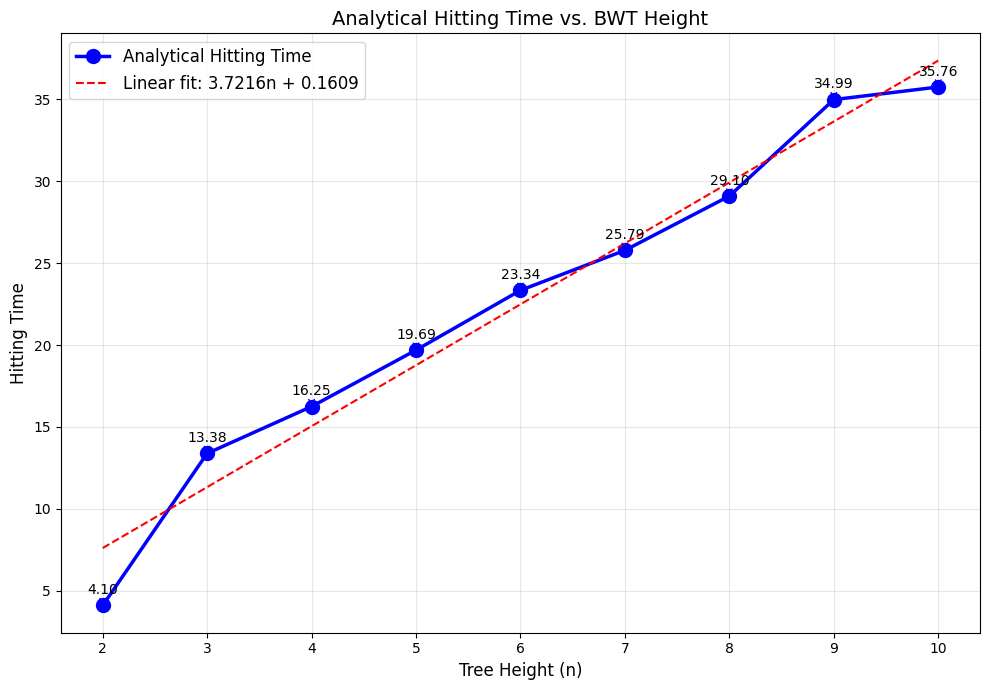

(<Figure size 1000x700 with 1 Axes>,
 [{'height': 2,
   'hitting_time': 4.0969226271100805,
   'max_probability': 0.343896774908573,
   'computation_time': 0.007997274398803711},
  {'height': 3,
   'hitting_time': 13.38357907614738,
   'max_probability': 0.1831904608499634,
   'computation_time': 0.010395526885986328},
  {'height': 4,
   'hitting_time': 16.247706029450818,
   'max_probability': 0.16273277880150747,
   'computation_time': 0.019205808639526367},
  {'height': 5,
   'hitting_time': 19.693717021680175,
   'max_probability': 0.134707262097367,
   'computation_time': 0.030992507934570312},
  {'height': 6,
   'hitting_time': 23.344554560083754,
   'max_probability': 0.10949846319200054,
   'computation_time': 0.06973385810852051},
  {'height': 7,
   'hitting_time': 25.787615618265114,
   'max_probability': 0.09479823490893544,
   'computation_time': 0.25446557998657227},
  {'height': 8,
   'hitting_time': 29.10255063507738,
   'max_probability': 0.08783784197757323,
   'comput

In [3]:
print("=== Binary Welded Tree Quantum Walk Analysis ===")
print("\nAnalyzing analytical hitting times for different tree heights...")

# Use gradient-based optimization (faster)
analyze_analytical_hitting_times(heights=range(2, 11), optimization_method='gradient')